## Project Name: Wine Quality Prediction __ Regression Problem

## 1) Problem statement.

- Our team works for a wine manufacturing company that produces red wine for commercial distribution. The objective is to develop a machine learning model that can predict wine quality scores based on physicochemical test results, helping the company improve quality control and optimize production processes.

### 2)  Import Data

In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Import the CSV Data as Pandas DataFrame**

In [5]:
# load the dataset
df = pd.read_csv("../data/winequality-red.csv")

**Show Top 5 Records**

In [6]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


**Shape of the dataset**

In [7]:
# shape
df.shape

(1599, 12)

**Summary of the dataset**

In [8]:
# Display summary statistics for a dataframe
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.319637,1.741096,4.60000,7.1000,7.90000,9.200000,15.90000
volatile acidity,1599.0,0.527821,0.179060,0.12000,0.3900,0.52000,0.640000,1.58000
citric acid,1599.0,0.270976,0.194801,0.00000,0.0900,0.26000,0.420000,1.00000
residual sugar,1599.0,2.538806,1.409928,0.90000,1.9000,2.20000,2.600000,15.50000
chlorides,1599.0,0.087467,0.047065,0.01200,0.0700,0.07900,0.090000,0.61100
free sulfur dioxide,1599.0,15.874922,10.460157,1.00000,7.0000,14.00000,21.000000,72.00000
total sulfur dioxide,1599.0,46.467792,32.895324,6.00000,22.0000,38.00000,62.000000,289.00000
density,1599.0,0.996747,0.001887,0.99007,0.9956,0.99675,0.997835,1.00369
pH,1599.0,3.311113,0.154386,2.74000,3.2100,3.31000,3.400000,4.01000
sulphates,1599.0,0.658149,0.169507,0.33000,0.5500,0.62000,0.730000,2.00000


### Statistical Inferences — Wine Quality Dataset

- The dataset contains 1,599 red wine samples, with the majority of wines having a quality score between 5 and 6 (Median = 6, Mean = 5.64), indicating that most wines are of average quality.

- Features such as Total Sulfur Dioxide, Residual Sugar, Chlorides, and Sulphates show a large gap between the 75th percentile and maximum values, suggesting right-skewed distributions and potential outliers.

- Alcohol content (Mean = 10.42) shows moderate variability and is likely an important predictor, as its spread is relatively balanced compared to highly skewed chemical features.

- Variables like Density and pH have very small standard deviations, indicating stable and near-normally distributed features with minimal extreme values.

**Overall, the dataset contains a mix of stable chemical properties and highly skewed features, which suggests that outlier handling and feature scaling may be important during model development.**

**Check Datatypes in the dataset**

In [9]:
# Data Type
df.dtypes

fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

## 3. EXPLORING DATA

**Most of the features seems to be of object data type, Now let's seperate Categorical and numerical columns**

In [10]:
# target column
target_feature = 'quality'

In [11]:
# Seperate Numerical and Categorical Columns

# define numerical & categorical columns
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']

# print columns
print('We have {} numerical features : {}'.format(len(numeric_features), numeric_features))
print('\nWe have {} categorical features : {}'.format(len(categorical_features), categorical_features))


We have 12 numerical features : ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']

We have 0 categorical features : []


## Univariate Analysis

**The term univariate analysis refers to the analysis of one variable prefix “uni” means “one.” The purpose of univariate analysis is to understand the distribution of values for a single variable.**

### 1. Numerical Features

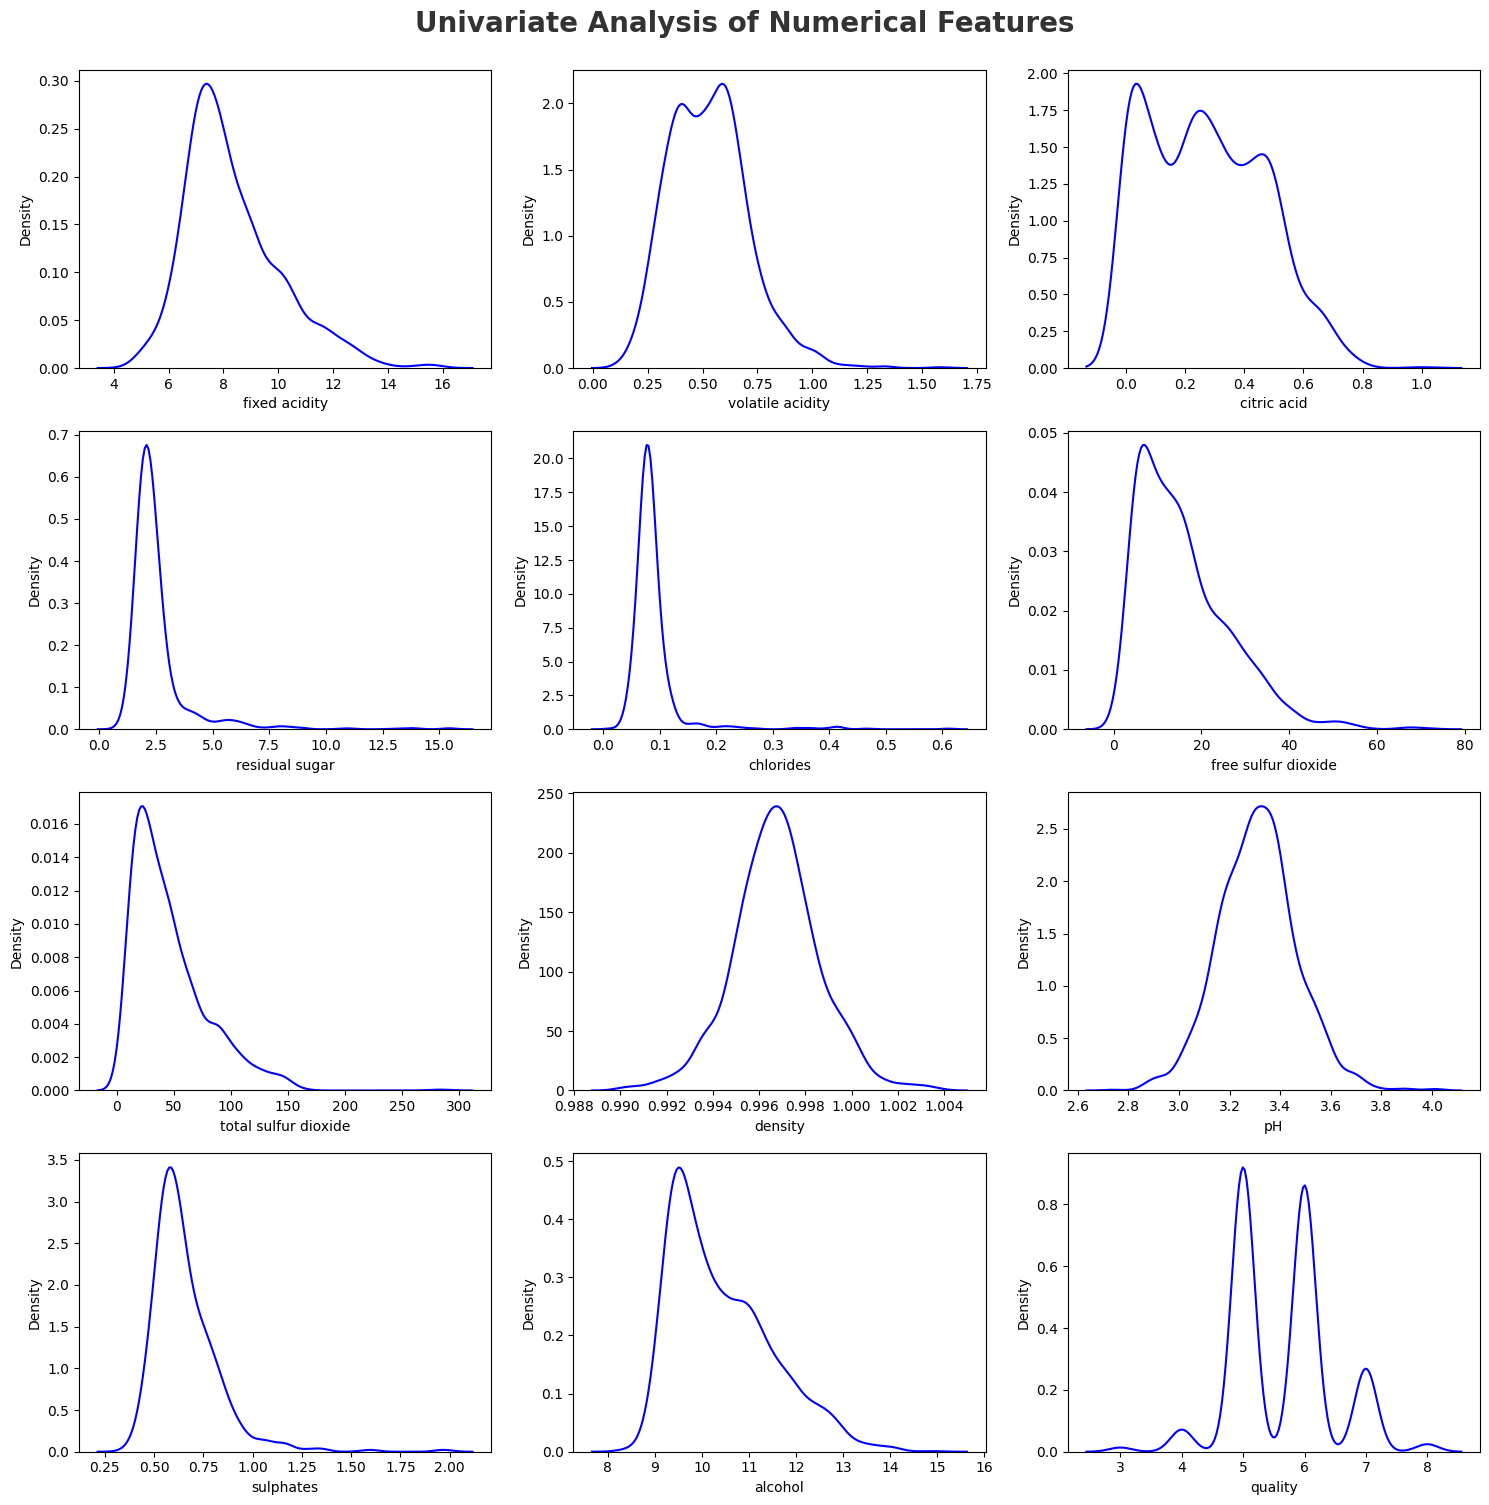

In [13]:
# Numerical Feature Distribution -- kdeplot
import math

plt.figure(figsize=(15, 15))
plt.suptitle('Univariate Analysis of Numerical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1.)

# Dynamically calculate rows and columns
num_features = len(numeric_features)
cols = 3
rows = math.ceil(num_features / cols)

for i in range(0, num_features):
    plt.subplot(rows, cols, i+1)
    sns.kdeplot(x=df[numeric_features[i]], color='blue')
    plt.xlabel(numeric_features[i])
    plt.tight_layout()

plt.show()

<font size=3>**Report**</font>

* <font size=3>`Residual Sugar`, `Chlorides`, `Free Sulfur Dioxide`, `Total Sulfur Dioxide`, and `Sulphates` are **positively skewed**, indicating that most wines have lower values while a few samples contain very high values.</font>

* <font size=3>`Fixed Acidity` also shows slight **right skewness**, suggesting the presence of some wines with unusually high acidity levels.</font>

* <font size=3>`Density` and `pH` appear to be relatively **normally distributed**, with values concentrated around their mean and fewer extreme observations.</font>

* <font size=3>`Alcohol` shows a mildly skewed distribution, and higher alcohol values may be important for predicting better wine quality.</font>

* <font size=3>`Quality` is a discrete target variable and is mostly concentrated around scores **5 and 6**, meaning the dataset contains mostly average-quality wines and fewer low/high-quality wines.</font>

* <font size=3>The skewed features may contain **outliers**, so outlier analysis and feature scaling should be considered before model training.</font>

<font size=5>**Checking the Null Values in dataset**</font>


In [14]:
# Null Value checking
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

**Insights**

- There are 7 columns which has null values

## Multivariate Analysis
* Multivariate analysis is the analysis of more than one variable.

<font size=5>**Correlation in Numerical Features**</font>

In [15]:
# list of numerical features
numeric_features

['fixed acidity',
 'volatile acidity',
 'citric acid',
 'residual sugar',
 'chlorides',
 'free sulfur dioxide',
 'total sulfur dioxide',
 'density',
 'pH',
 'sulphates',
 'alcohol',
 'quality']

In [16]:
df[(list(df.columns)[1:])].corr(numeric_only=True)

,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
volatile acidity,1.000000,-0.552496,0.001918,0.061298,-0.010504,0.076470,0.022026,0.234937,-0.260987,-0.202288,-0.390558
citric acid,-0.552496,1.000000,0.143577,0.203823,-0.060978,0.035533,0.364947,-0.541904,0.312770,0.109903,0.226373
residual sugar,0.001918,0.143577,1.000000,0.055610,0.187049,0.203028,0.355283,-0.085652,0.005527,0.042075,0.013732
chlorides,0.061298,0.203823,0.055610,1.000000,0.005562,0.047400,0.200632,-0.265026,0.371260,-0.221141,-0.128907
free sulfur dioxide,-0.010504,-0.060978,0.187049,0.005562,1.000000,0.667666,-0.021946,0.070377,0.051658,-0.069408,-0.050656
total sulfur dioxide,0.076470,0.035533,0.203028,0.047400,0.667666,1.000000,0.071269,-0.066495,0.042947,-0.205654,-0.185100
density,0.022026,0.364947,0.355283,0.200632,-0.021946,0.071269,1.000000,-0.341699,0.148506,-0.496180,-0.174919
pH,0.234937,-0.541904,-0.085652,-0.265026,0.070377,-0.066495,-0.341699,1.000000,-0.196648,0.205633,-0.057731
sulphates,-0.260987,0.312770,0.005527,0.371260,0.051658,0.042947,0.148506,-0.196648,1.000000,0.093595,0.251397
alcohol,-0.202288,0.109903,0.042075,-0.221141,-0.069408,-0.205654,-0.496180,0.205633,0.093595,1.000000,0.476166


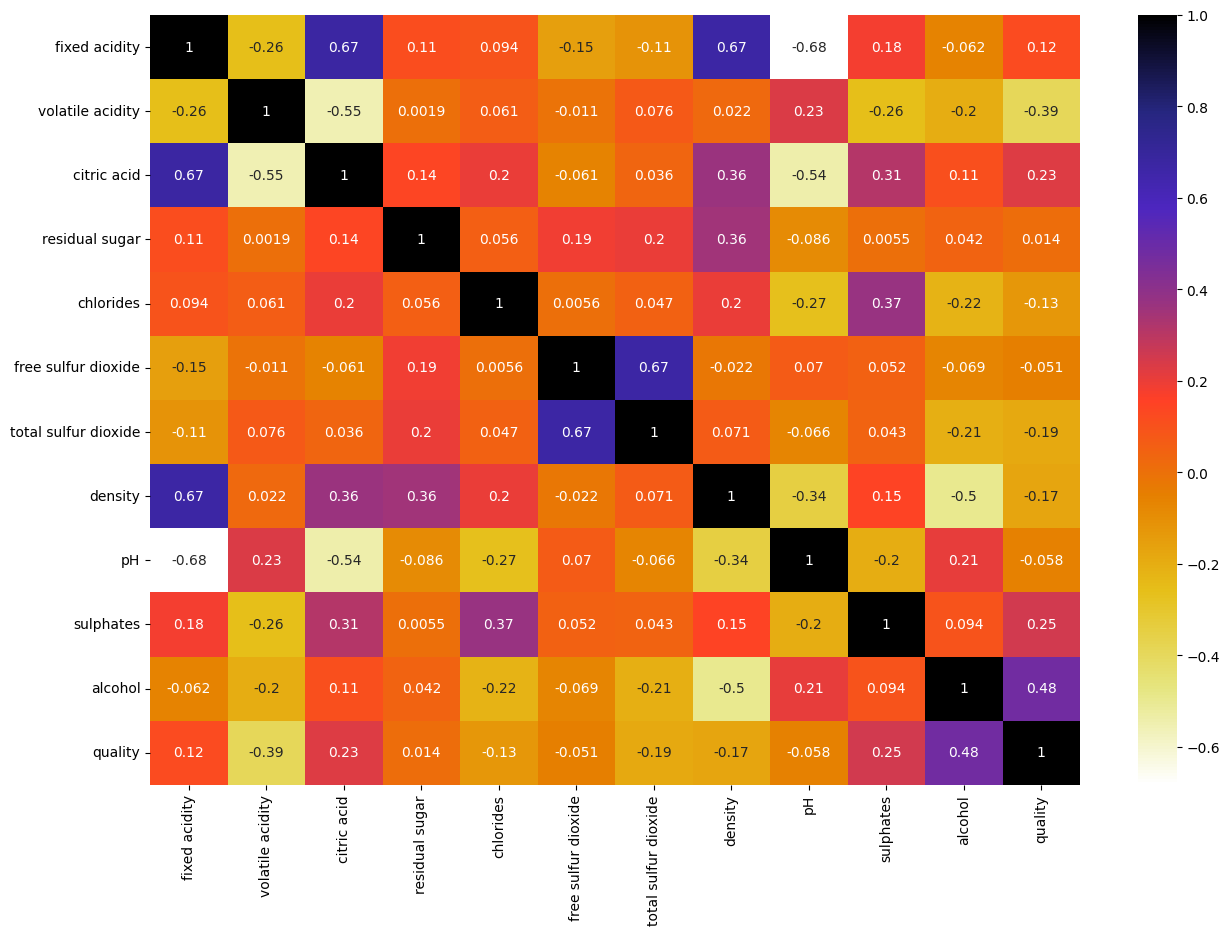

In [17]:
# heatmap
plt.figure(figsize = (15,10))
sns.heatmap(df.corr(numeric_only=True), cmap="CMRmap_r", annot=True)
plt.show()

**Insights**
- There is a high correlation between 
    - `fixed acidity` -  `citric acid`, `density`
    - `free sulfur dioxide` - `total sulfur dioxide`  and
    - `alcohol` -  `quality`    
    

In [18]:
df.head(2)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.0,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.0,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5


### Relationship between target and numerical columns

C:\Users\kz\AppData\Local\Temp\ipykernel_31056\2910748238.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target_feature, y=feature, palette="Blues", ax=ax)
C:\Users\kz\AppData\Local\Temp\ipykernel_31056\2910748238.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target_feature, y=feature, palette="Blues", ax=ax)
C:\Users\kz\AppData\Local\Temp\ipykernel_31056\2910748238.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target_feature, y=feature, palette="Blues", ax=ax)
C:\Users\kz\AppData\Local\Te

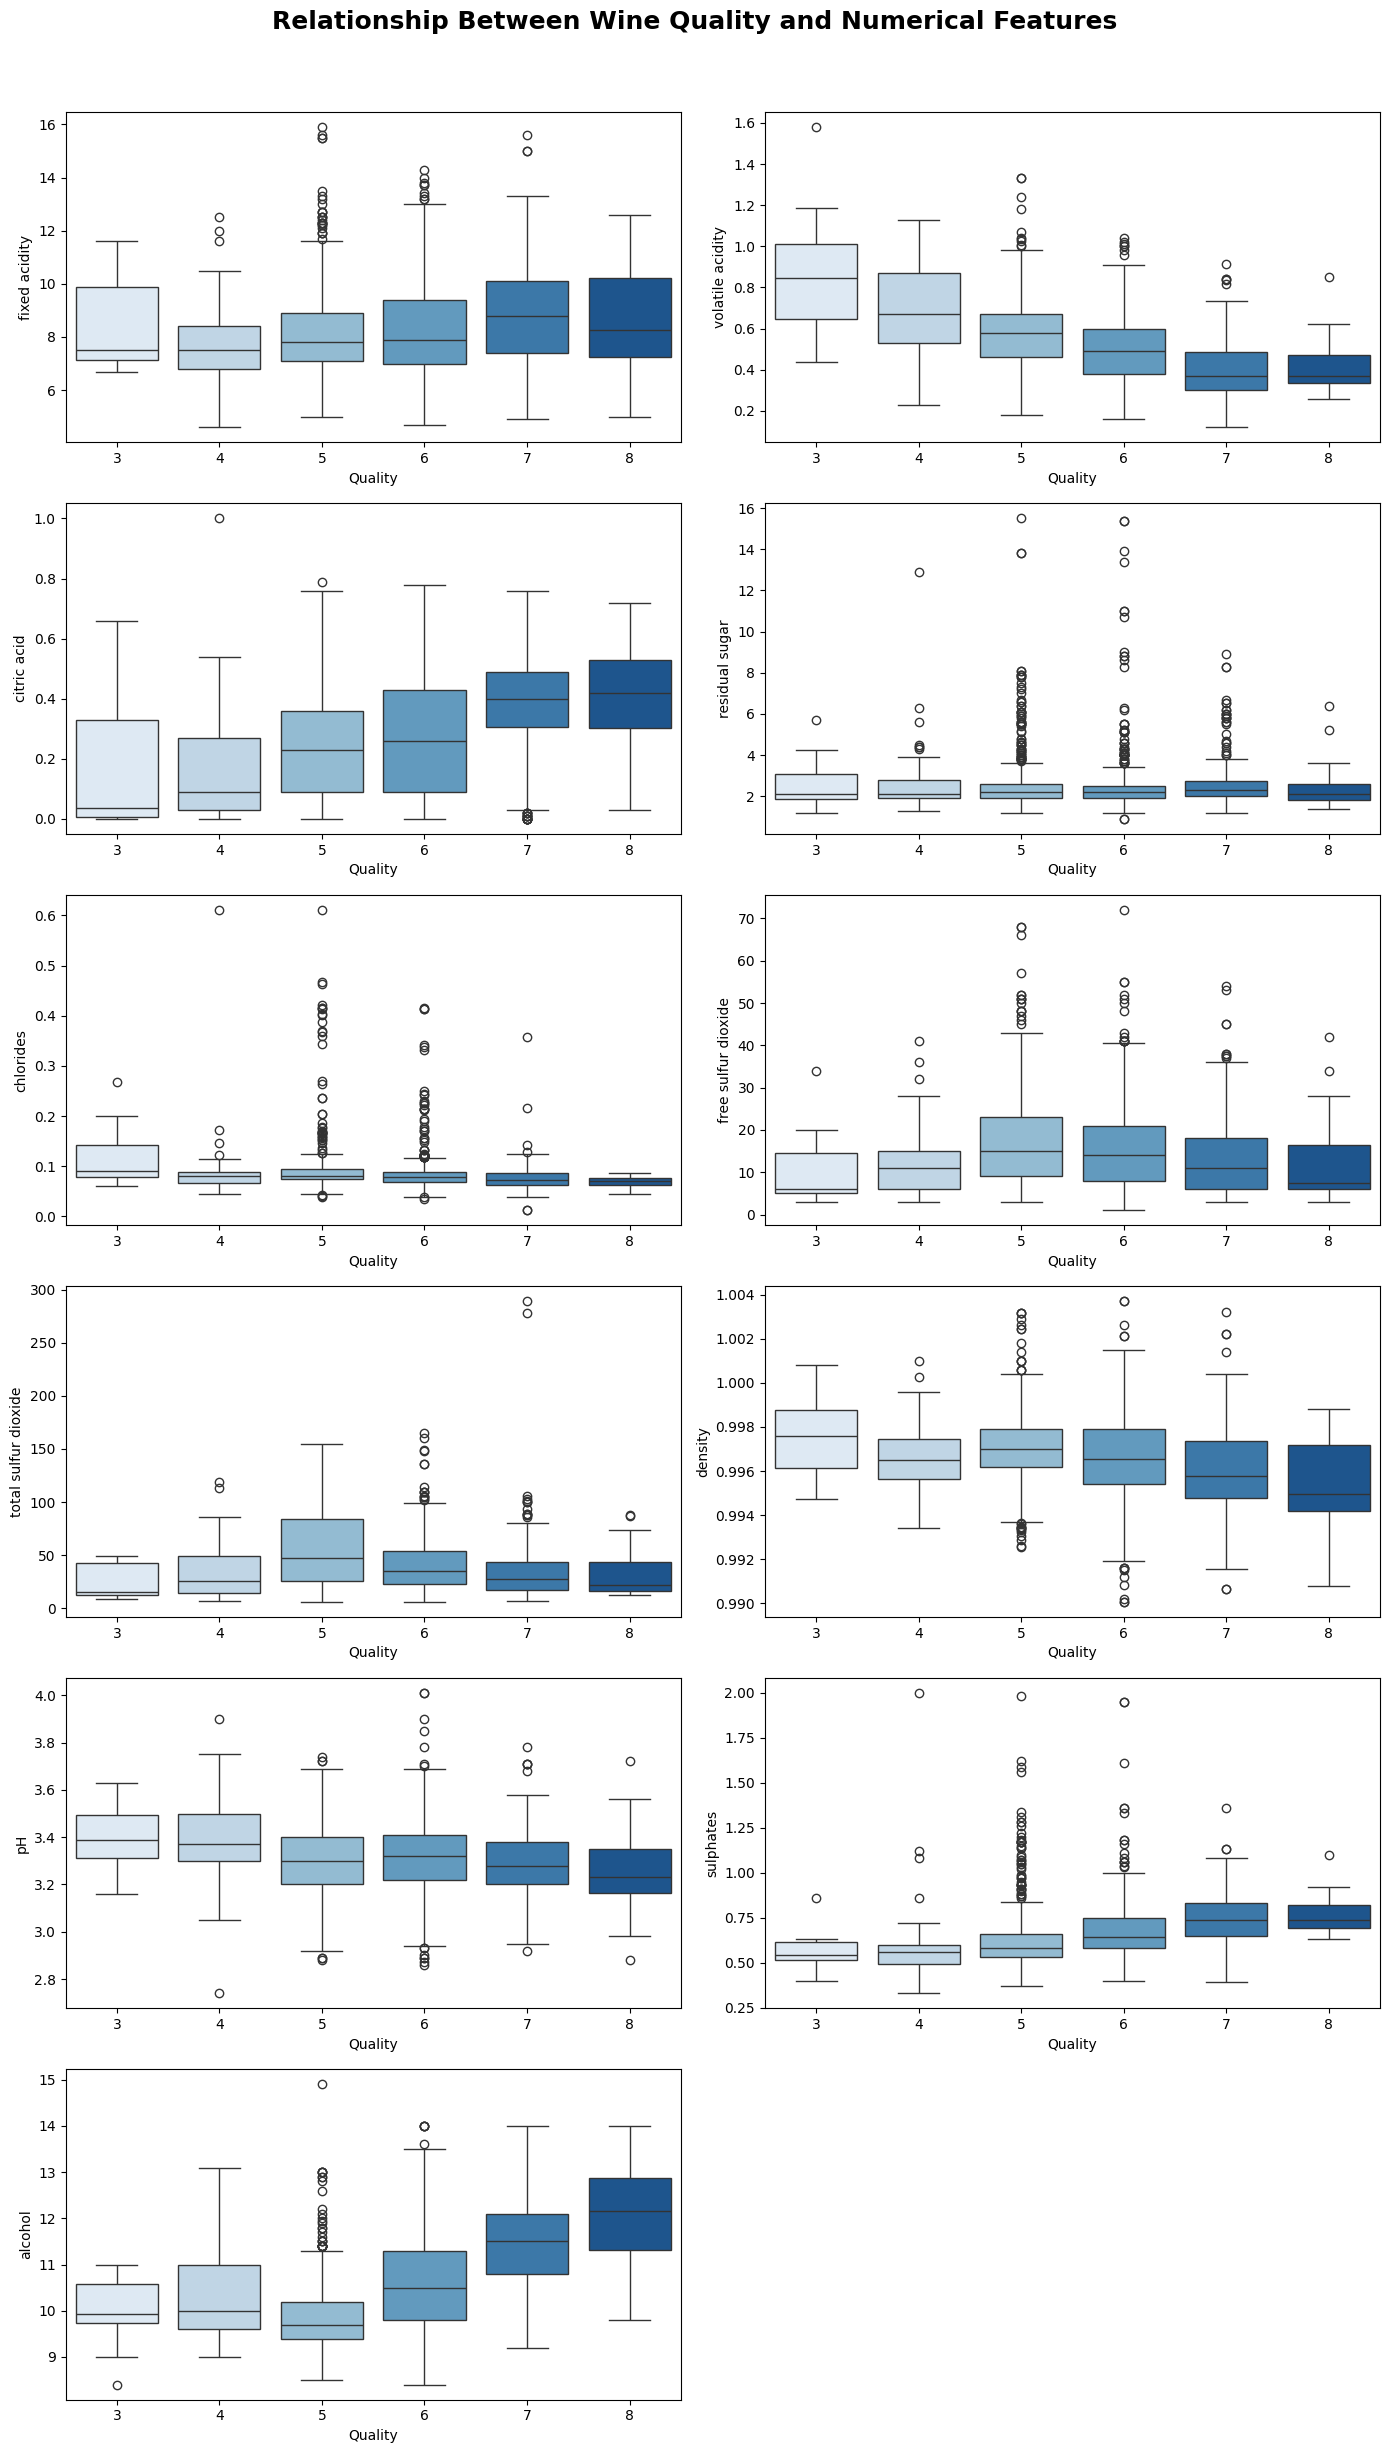

In [ ]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

target_feature = "quality"
numeric_features = [col for col in df.columns if col != target_feature]

cols = 2
rows = math.ceil(len(numeric_features) / cols)

plt.figure(figsize=(14, rows * 4))
plt.suptitle("Relationship Between Wine Quality and Numerical Features",
             fontsize=18, fontweight='bold', y=1.02)

for i, feature in enumerate(numeric_features, 1):
    ax = plt.subplot(rows, cols, i)
    
    sns.boxplot(data=df, x=target_feature, y=feature, palette="Blues", ax=ax)
    
    ax.set_xlabel("Quality")
    ax.set_ylabel(feature)

plt.tight_layout()
plt.show()


<font size=3>**Report**</font>

* <font size=3>`Alcohol` has a strong **positive relationship** with `Quality`. Wines with higher quality scores (7 and 8) tend to have significantly higher alcohol content compared to lower-quality wines.</font>

* <font size=3>`Volatile Acidity` shows a distinct **negative relationship** with `Quality`. Lower quality wines have higher volatile acidity, which is known to cause an unpleasant, vinegar-like fault in wine.</font>

* <font size=3>`Citric Acid` and `Sulphates` display a **positive trend** with `Quality`. Higher-rated wines generally contain slightly higher levels of these chemicals, which contribute to freshness, flavor, and preservation.</font>

* <font size=3>Features like `Residual Sugar`, `pH`, and `Fixed Acidity` show **minimal variance** or very weak relationships across the different quality categories.</font>

* <font size=3>The plots confirm the presence of **many outliers** within specific features (like `Chlorides` and `Total Sulfur Dioxide`), particularly in the mid-tier quality classes (5 and 6), since the majority of the dataset is concentrated there.</font>

---

**Shall we move on to the Correlation Heatmap next to mathematically prove these relationships?** 📊🍷

## Visualizing Independent columns

In [21]:
df.head(2)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.0,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.0,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5


<font size=5>**Target Feature**</font>


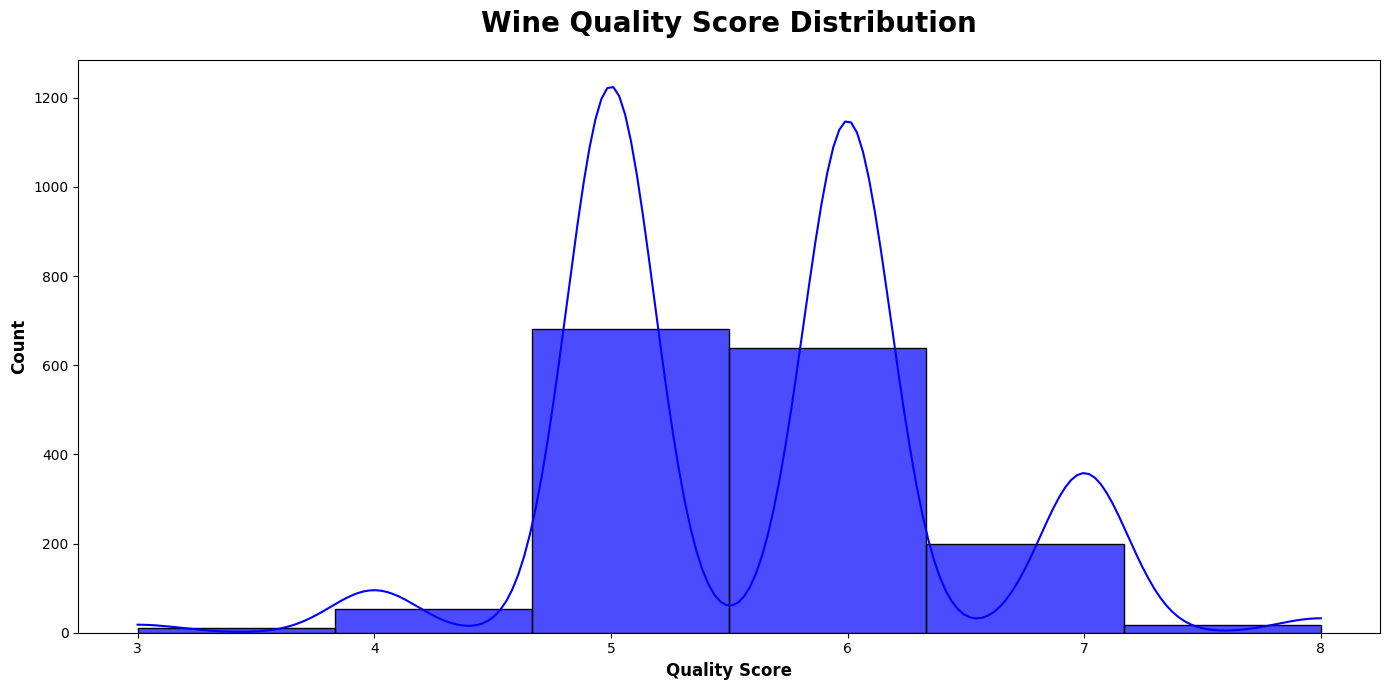

In [27]:
# Target Feature Distribution
plt.subplots(figsize=(14, 7))
sns.histplot(df[target_feature], bins=6, kde=True, color='blue', alpha=0.7)
plt.title("Wine Quality Score Distribution", weight="bold", fontsize=20, pad=20)
plt.ylabel("Count", weight="bold", fontsize=12)
plt.xlabel("Quality Score", weight="bold", fontsize=12)
plt.xticks([3, 4, 5, 6, 7, 8])
plt.tight_layout()
plt.show()

#### Report

- The Quality Score distribution is approximately normal but slightly left-skewed, with the majority of wines concentrated around scores 5 and 6.

- Extreme quality scores (3 and 8) are very rare, meaning the dataset is heavily imbalanced toward average-quality wines — this could challenge model performance on edge cases.

- The dataset contains very few exceptional wines (quality 7–8) and very few poor wines (quality 3–4), making it harder for the model to learn patterns at the extremes.



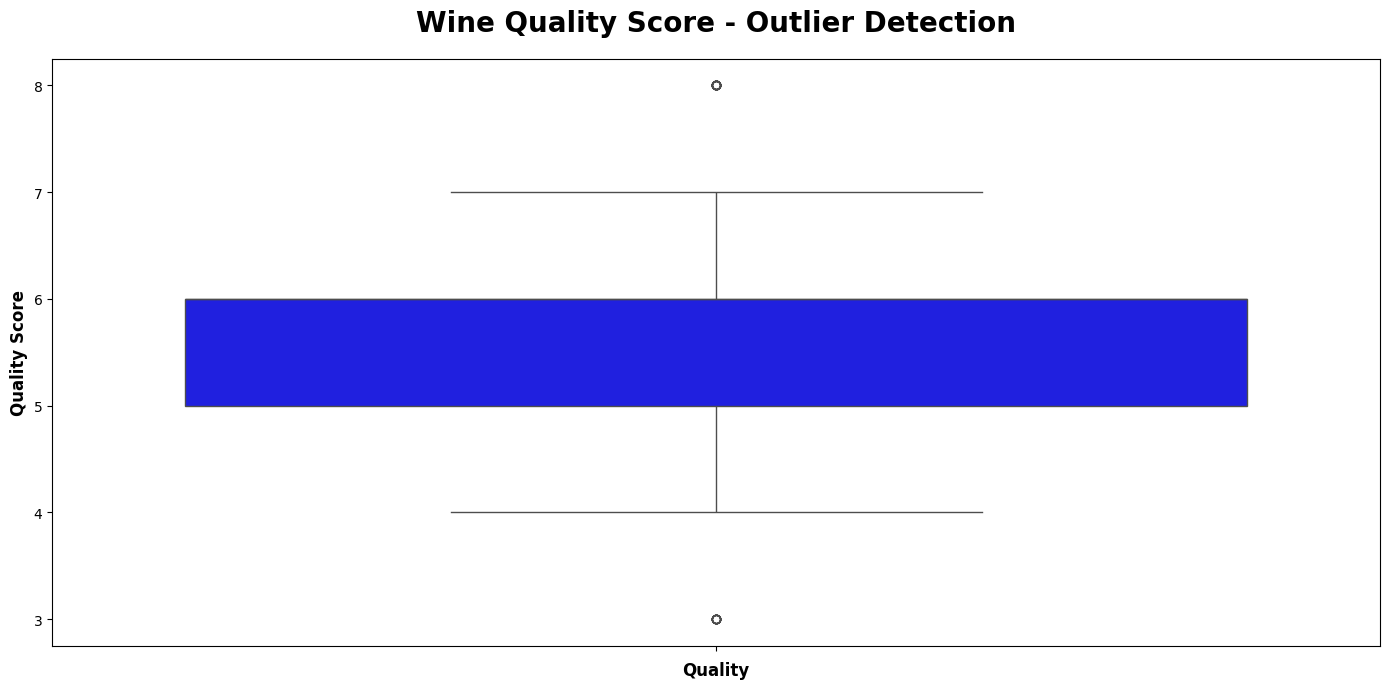

In [28]:
# To see the outlier in the target feature
plt.subplots(figsize=(14, 7))
sns.boxplot(df[target_feature], color='blue')
plt.title("Wine Quality Score - Outlier Detection", weight="bold", fontsize=20, pad=20)
plt.ylabel("Quality Score", weight="bold", fontsize=12)
plt.xlabel("Quality", weight="bold", fontsize=12)
plt.tight_layout()
plt.show()

<font size=5>Report</font>

<font size=4>The boxplot confirms that the median quality score is 6, with the interquartile range (IQR) sitting between 5 and 6 — indicating that most wines are of average quality.</font>

<font size=4>Quality scores of 3 appear as outliers on the lower end, suggesting that very poor quality wines are extremely rare in this dataset.</font>

<font size=4>Since the target variable Quality is a discrete and bounded variable (3–8), the outliers observed are natural boundary values rather than data entry errors, so no outlier removal is needed for the target column.</font>

## Grouped Barplot for Wine Quality

In [29]:
df.head(2)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.0,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.0,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5


C:\Users\kz\AppData\Local\Temp\ipykernel_31056\3845597451.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=alcohol_group.index, y=alcohol_group.values, ec="black", palette="Set2")


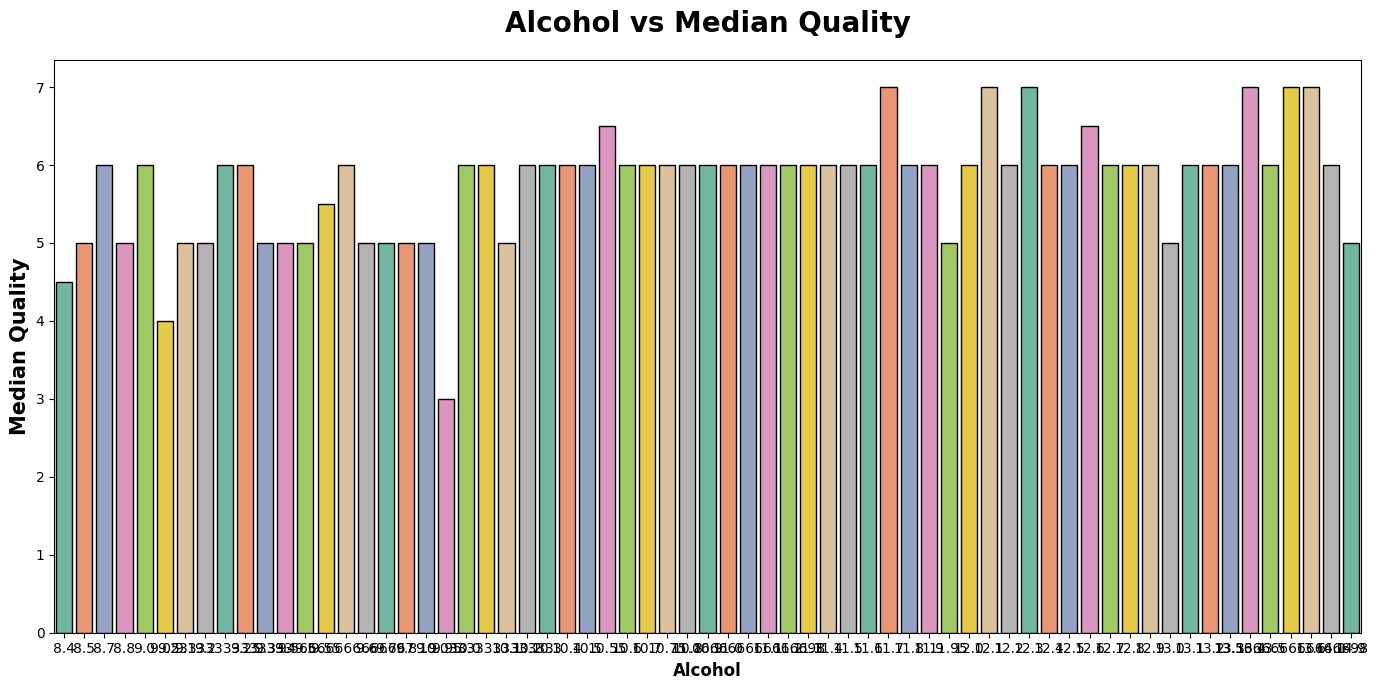

In [35]:
alcohol_group = df.groupby('alcohol')[target_feature].median()

plt.subplots(figsize=(14, 7))
sns.barplot(x=alcohol_group.index, y=alcohol_group.values, ec="black", palette="Set2")
plt.title("Alcohol vs Median Quality", weight="bold", fontsize=20, pad=20)
plt.ylabel("Median Quality", weight="bold", fontsize=15)
plt.xlabel("Alcohol", weight="bold", fontsize=12)
plt.tight_layout()
plt.show()

C:\Users\kz\AppData\Local\Temp\ipykernel_31056\1263960027.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


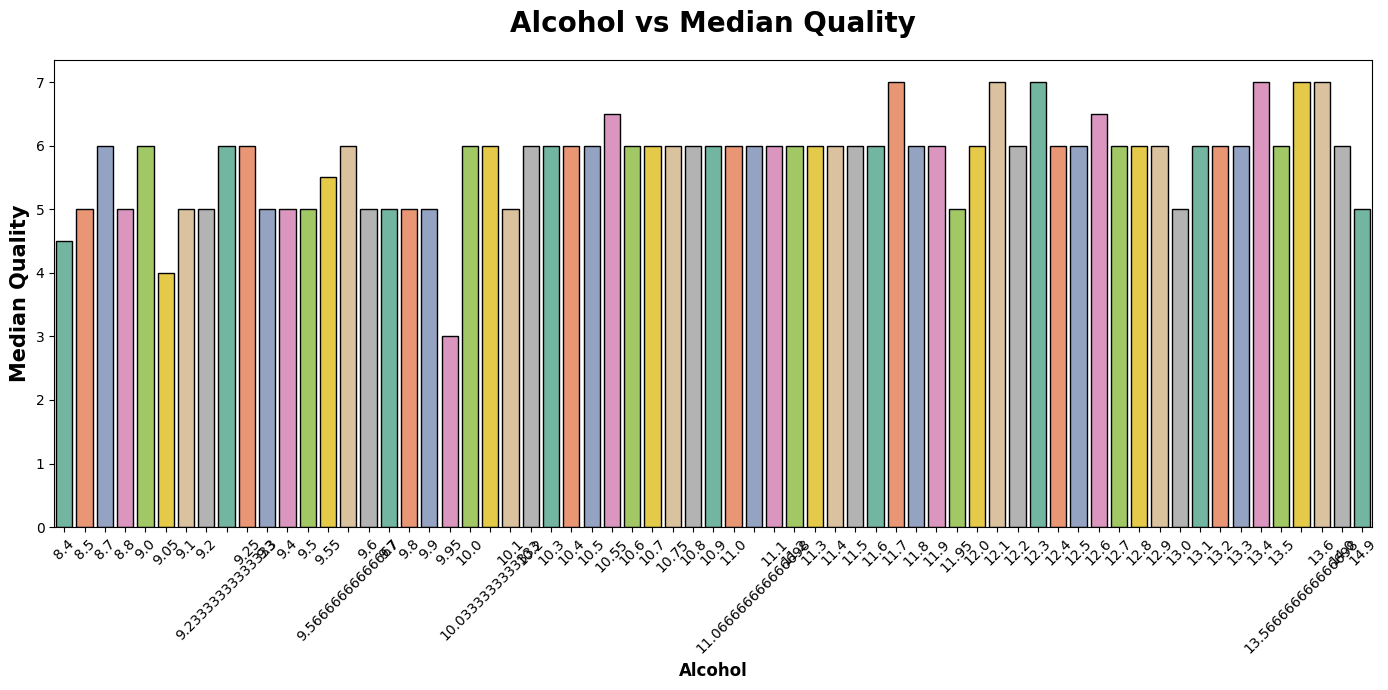

C:\Users\kz\AppData\Local\Temp\ipykernel_31056\1263960027.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


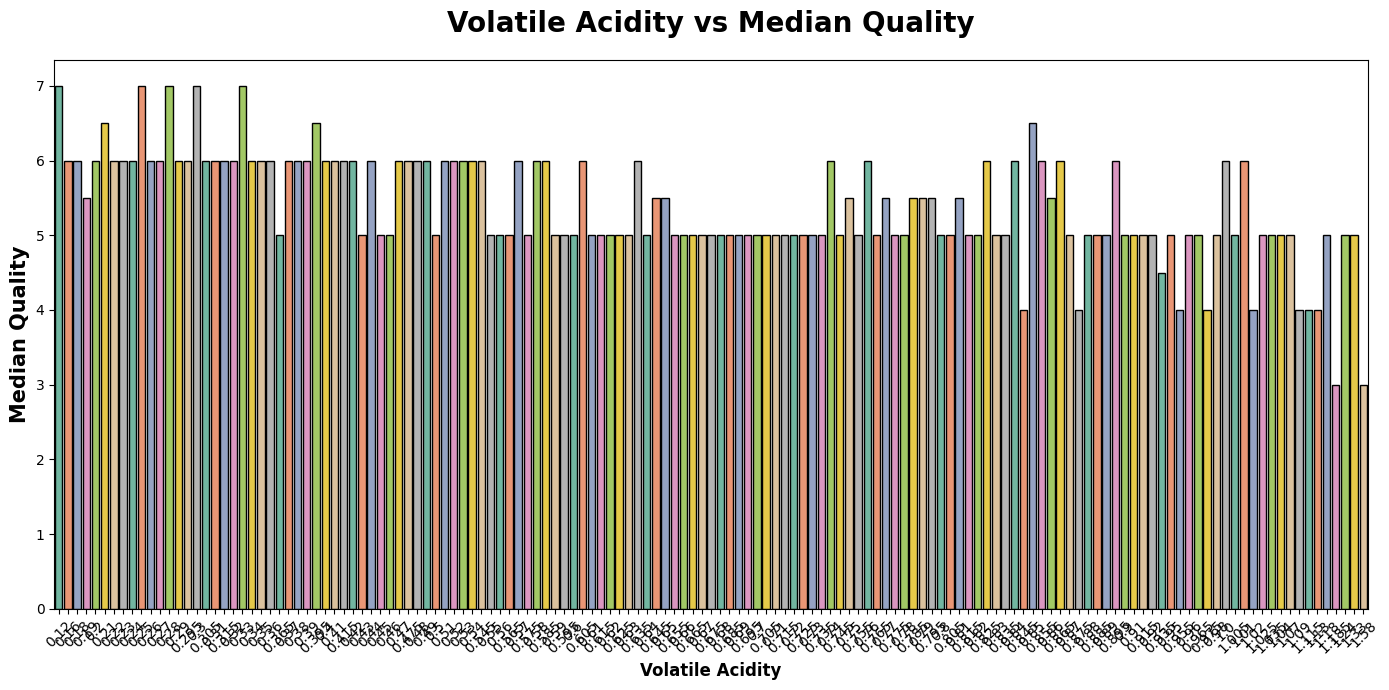

C:\Users\kz\AppData\Local\Temp\ipykernel_31056\1263960027.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


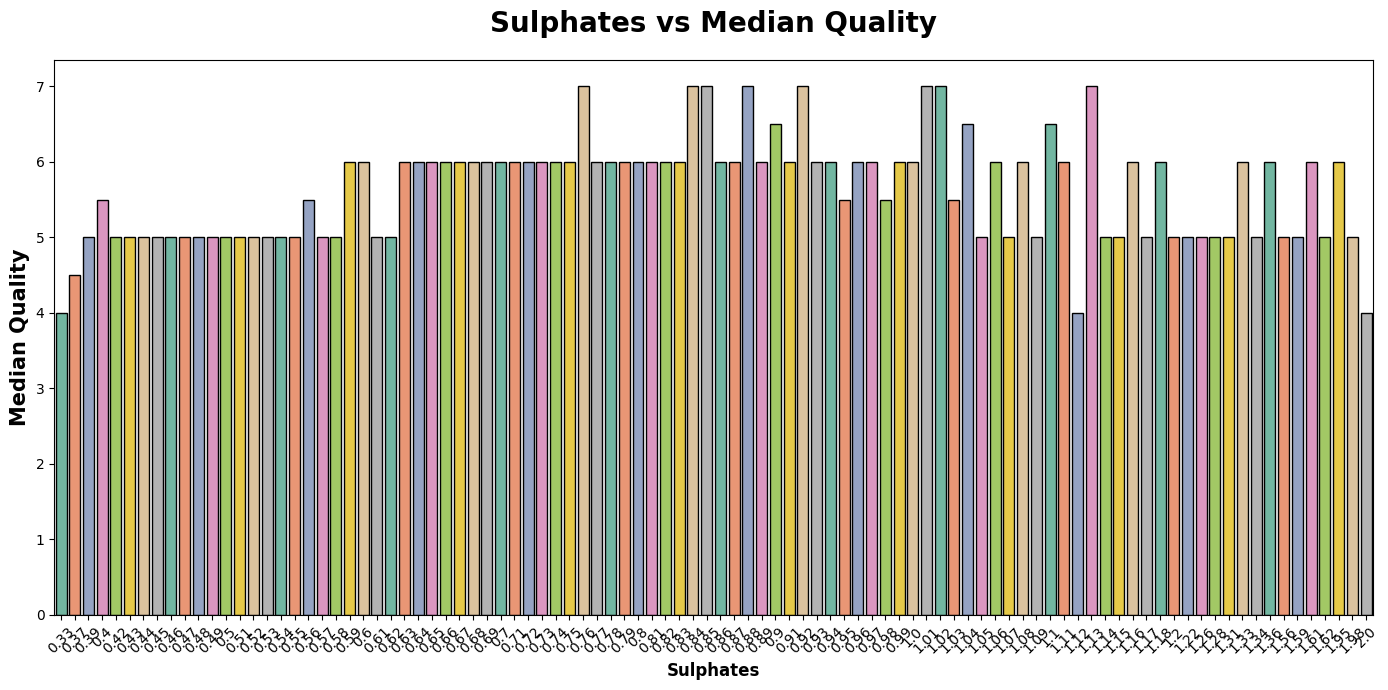

C:\Users\kz\AppData\Local\Temp\ipykernel_31056\1263960027.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


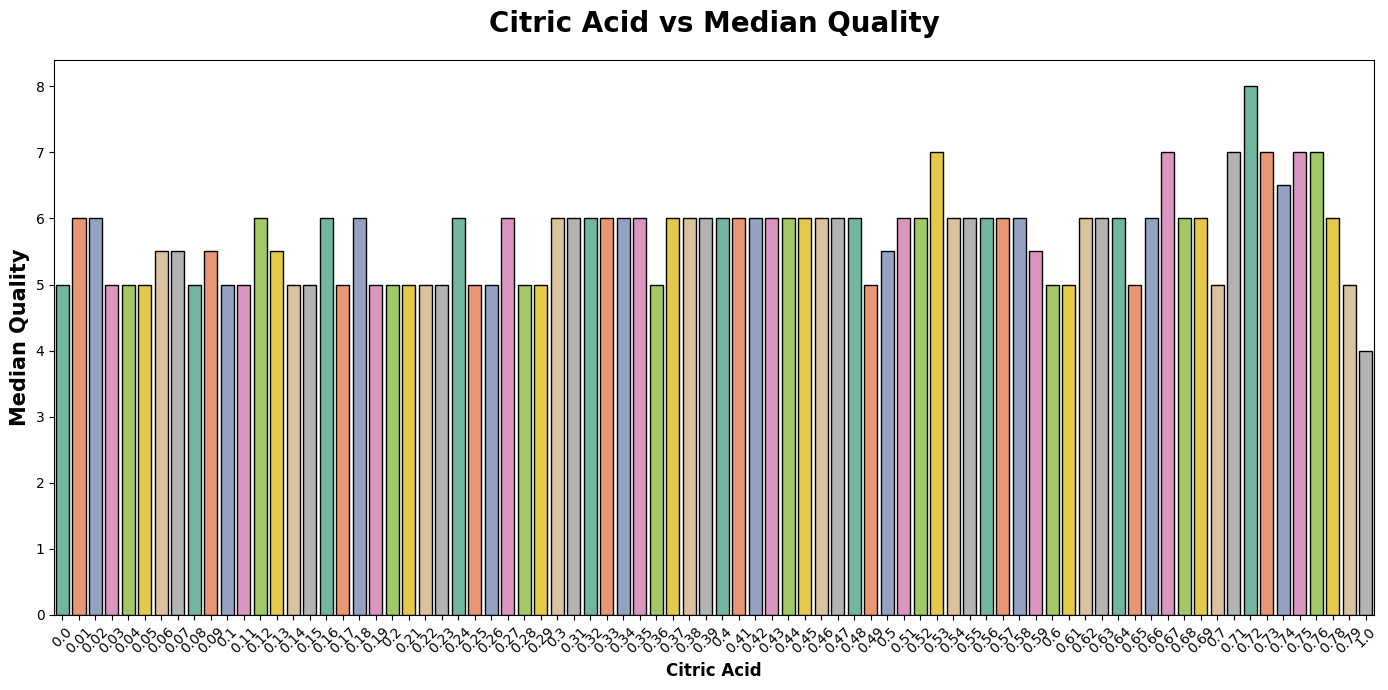

C:\Users\kz\AppData\Local\Temp\ipykernel_31056\1263960027.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


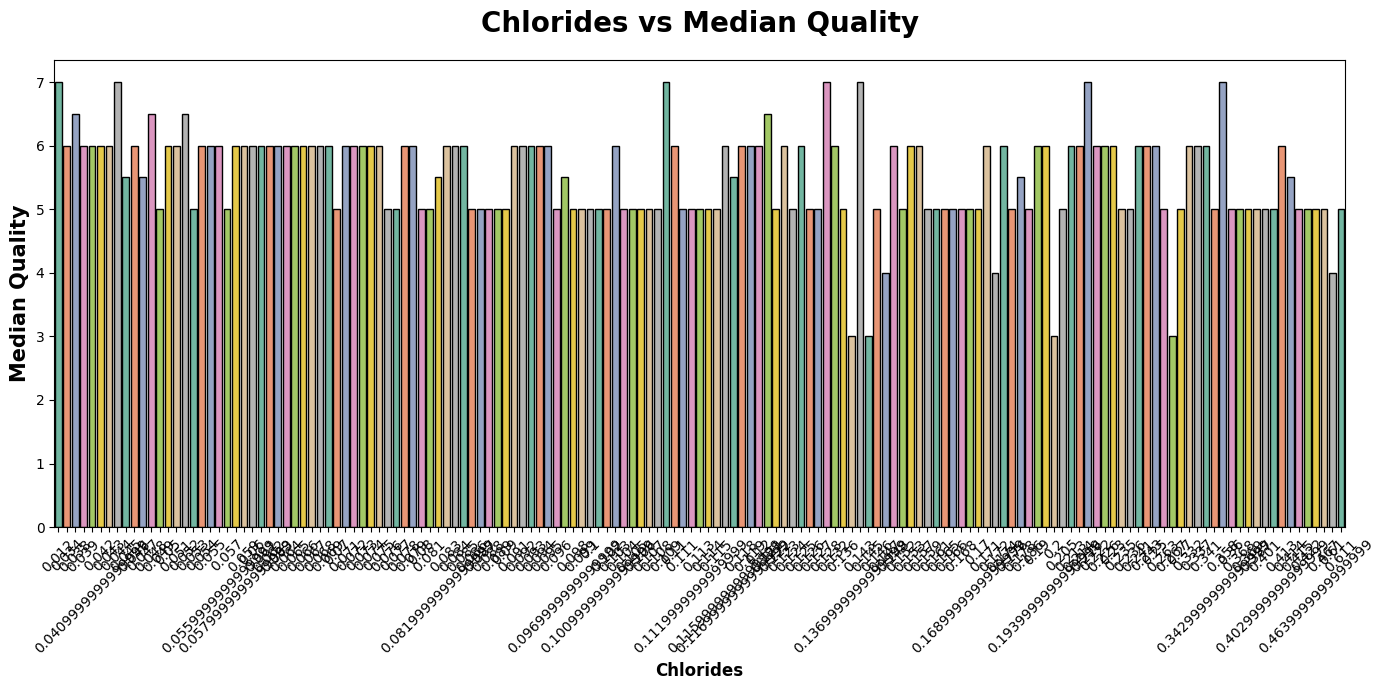

In [36]:
# Most informative features for groupby analysis
group_features = [
    'alcohol',
    'volatile acidity',
    'sulphates',
    'citric acid',
    'chlorides'
]

for feature in group_features:
    feature_group = df.groupby(feature)[target_feature].median()

    plt.subplots(figsize=(14, 7))
    sns.barplot(
        x=feature_group.index,
        y=feature_group.values,
        ec="black",
        palette="Set2"
    )
    plt.title(f"{feature.title()} vs Median Quality",
              weight="bold", fontsize=20, pad=20)
    plt.ylabel("Median Quality", weight="bold", fontsize=15)
    plt.xlabel(feature.title(), weight="bold", fontsize=12)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Final Report

* The `Quality` column is the target to predict.

* The target variable here is **discrete and numerical**, ranging from **3 to 8**, and will be treated as a **regression problem**.

* Features like `Total Sulfur Dioxide`, `Residual Sugar`, `Chlorides`, and `Sulphates` are **positively skewed** and contain **potential outliers** that need to be handled before model training.

* `Volatile Acidity`, `Chlorides`, and `Total Sulfur Dioxide` contain **extreme outlier values** that may negatively impact model performance and should be treated using **IQR-based or capping methods**.

* All features are **numerical** — there are **no categorical columns** and **no date columns** to extract or encode in this dataset.

* The dataset contains **no missing values**, so no imputation strategy is required.

* Features like `Alcohol`, `Volatile Acidity`, `Sulphates`, and `Citric Acid` show the **strongest relationship** with the target variable `Quality` and are expected to be the **most important predictors**.

* Features like `Density`, `pH`, and `Fixed Acidity` show **weak or minimal correlation** with `Quality` and may have **low feature importance** during model training.

* **Feature Scaling** (StandardScaler or MinMaxScaler) is recommended since features have **very different ranges and units** (e.g., `Total Sulfur Dioxide` vs `Density`).

* The dataset is **moderately imbalanced** at the target level — quality scores **5 and 6 dominate**, while scores **3 and 8 are very rare**, which may affect the model's ability to predict edge cases accurately.